## Handwritten Digits Classification

This project builds a model that recognizes handwritten digits (0-9) from images. Each image is turned into numbers (pixel values), and a classification model learns which pixel patterns belong to which digit. The objective is correctly predict the digit shown in an image, and understand which digits the model confuses.

## Approach
1. Load the data and look at sample images
2. Check the class balance and the pixel value range
3. Flatten the images into 64 features and scale them
4. Split the data into training and test sets
5. Train several classifiers (Logistic Regression, KNN, SVM, Random Forest)
6. Evaluate them with accuracy, classification report, and confusion matrix
7. Look at the misclassified images to see where the model fails
8. Show at Streamlit.io

In [1]:
# 1. Load the data
from sklearn.datasets import load_digits
digits = load_digits()
x, y = digits.data, digits.target

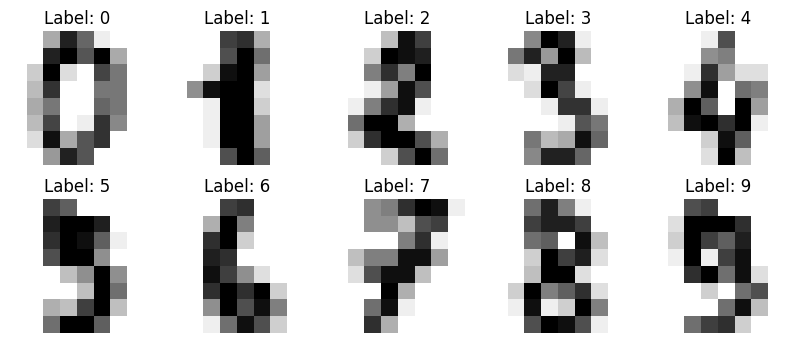

In [2]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, img, label in zip(axes.ravel(), digits.images, digits.target):
    ax.imshow(img, cmap='gray_r')
    ax.set_title(f'Label: {label}')
    ax.axis('off')
plt.show()

In [3]:
# Check the class balance
import numpy as np
import pandas as pd

print(x.shape, y.shape)
print(pd.Series(y).value_counts().sort_index())
print(x.min(), x.max())

(1797, 64) (1797,)
0    178
1    182
2    177
3    183
4    181
5    182
6    181
7    179
8    174
9    180
Name: count, dtype: int64
0.0 16.0


In [5]:
# 3 - Already done as load_digits()
# digits = load_digits()

In [6]:
# 4- Split the data
import sklearn
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [9]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [10]:
# 5 - Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import BernoulliNB

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

b = BernoulliNB()
l = LogisticRegression()
d = DecisionTreeClassifier()
r = RandomForestClassifier()
gb= GradientBoostingClassifier()
kn= KNeighborsClassifier()
ab= AdaBoostClassifier()
mn= MultinomialNB()

def algo_test(x, y):
    modeller=[ b, l, d, r, gb, kn, ab, mn]
    isimler=["BernoulliNB", "LogisticRegression", "DecisionTreeClassifier",
             "RandomForestClassifier", "GradientBoostingClassifier", "KNeighborsClassifier",
             "AdaBoostClassifier", "MultinomialNB"]

    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.20, random_state = 42)

    accuracy = []
    precision = []
    recall = []
    f1 = []
    mdl=[]

    print("Veriler hazır modeller deneniyor")
    for model in modeller:
        print(model, " modeli eğitiliyor!..")
        model=model.fit(x_train,y_train)
        tahmin=model.predict(x_test)
        mdl.append(model)
        accuracy.append(accuracy_score(y_test, tahmin))
        precision.append(precision_score(y_test, tahmin, average="micro"))
        recall.append(recall_score(y_test, tahmin, average="micro"))
        f1.append(f1_score(y_test, tahmin, average="micro"))
        print(confusion_matrix(y_test, tahmin))

    print("Eğitim tamamlandı.")

    metrics=pd.DataFrame(columns=["Accuracy", "Precision", "Recall", "F1", "Model"], index=isimler)
    metrics["Accuracy"] = accuracy
    metrics["Precision"] = precision
    metrics["Recall"] = recall
    metrics["F1"] = f1
    metrics["Model"]=mdl

    metrics.sort_values("F1", ascending=False, inplace=True)

    print("En başarılı model: ", metrics.iloc[0].name)
    model=metrics.iloc[0,-1]
    tahmin=model.predict(np.array(x_test) if model==kn else x_test)
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, tahmin))
    print("classification Report:")
    print(classification_report(y_test, tahmin))
    print("Diğer Modeller:")

    return metrics.drop("Model", axis=1)

In [11]:
algo_test(x, y)

Veriler hazır modeller deneniyor
BernoulliNB()  modeli eğitiliyor!..
[[31  0  0  0  2  0  0  0  0  0]
 [ 0 18  4  0  0  0  0  0  4  2]
 [ 0  1 29  2  0  0  0  0  1  0]
 [ 0  0  2 29  0  0  0  0  2  1]
 [ 0  0  0  0 45  0  0  1  0  0]
 [ 1  0  0  2  0 36  2  0  0  6]
 [ 0  0  0  0  1  0 34  0  0  0]
 [ 0  0  0  0  0  0  0 34  0  0]
 [ 0  3  1  0  0  0  0  0 24  2]
 [ 0  1  0  1  2  1  0  3  1 31]]
LogisticRegression()  modeli eğitiliyor!..


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[[33  0  0  0  0  0  0  0  0  0]
 [ 0 28  0  0  0  0  0  0  0  0]
 [ 0  0 33  0  0  0  0  0  0  0]
 [ 0  0  0 33  0  1  0  0  0  0]
 [ 0  1  0  0 44  0  1  0  0  0]
 [ 0  0  1  0  0 44  1  0  0  1]
 [ 0  0  0  0  0  1 34  0  0  0]
 [ 0  0  0  0  0  1  0 33  0  0]
 [ 0  0  0  0  0  1  0  0 29  0]
 [ 0  0  0  1  0  0  0  0  1 38]]
DecisionTreeClassifier()  modeli eğitiliyor!..
[[29  0  1  0  1  1  0  0  0  1]
 [ 0 22  1  1  1  0  0  1  1  1]
 [ 0  0 24  3  2  0  2  1  1  0]
 [ 0  0  1 30  0  0  0  0  2  1]
 [ 0  0  0  0 40  0  1  4  1  0]
 [ 0  0  0  0  2 40  1  0  0  4]
 [ 0  0  0  0  2  0 33  0  0  0]
 [ 0  0  0  2  1  0  0 31  0  0]
 [ 0  2  0  2  0  1  0  0 21  4]
 [ 0  0  0  2  2  0  0  4  0 32]]
RandomForestClassifier()  modeli eğitiliyor!..
[[33  0  0  0  0  0  0  0  0  0]
 [ 0 28  0  0  0  0  0  0  0  0]
 [ 0  0 33  0  0  0  0  0  0  0]
 [ 0  0  0 33  0  1  0  0  0  0]
 [ 0  0  0  0 46  0  0  0  0  0]
 [ 0  0  0  0  0 46  1  0  0  0]
 [ 0  0  0  0  0  1 34  0  0  0]
 [ 0  0  0  0

,Accuracy,Precision,Recall,F1
KNeighborsClassifier,0.986111,0.986111,0.986111,0.986111
RandomForestClassifier,0.972222,0.972222,0.972222,0.972222
GradientBoostingClassifier,0.969444,0.969444,0.969444,0.969444
LogisticRegression,0.969444,0.969444,0.969444,0.969444
MultinomialNB,0.911111,0.911111,0.911111,0.911111
BernoulliNB,0.863889,0.863889,0.863889,0.863889
DecisionTreeClassifier,0.838889,0.838889,0.838889,0.838889
AdaBoostClassifier,0.797222,0.797222,0.797222,0.797222


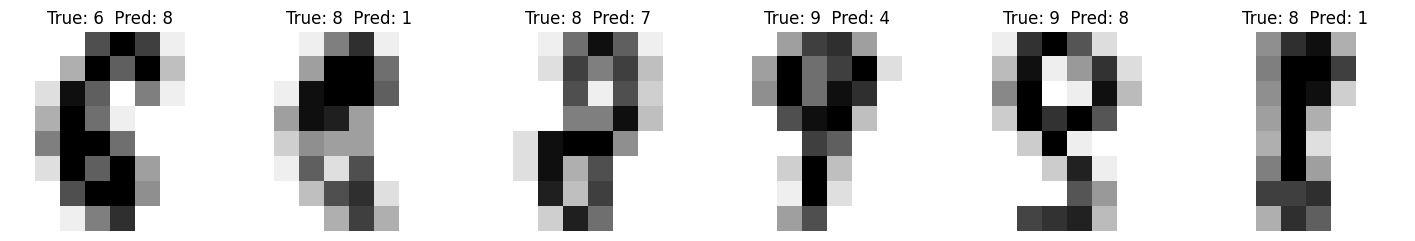

In [13]:
# 6- Wrong predictions, Confusion Matrix
# 7- Look at the misclassified images
knn = KNeighborsClassifier().fit(x_train, y_train)
pred = knn.predict(x_test)
wrong = np.where(pred != y_test)[0]

fig, axes = plt.subplots(1, len(wrong), figsize=(3 * len(wrong), 3))
for ax, i in zip(np.atleast_1d(axes), wrong):
    ax.imshow(x_test[i].reshape(8, 8), cmap='gray_r')
    ax.set_title(f'True: {y_test[i]}  Pred: {pred[i]}')
    ax.axis('off')
plt.show()

In [14]:
# Results and Conclusion
# We trained eight classifiers on the scikit-learn digits dataset (1,797 images, 8x8 pixels) and tested them on 360 images (20% of the data).
# Best model is  **K-Nearest Neighbors** - **98.6%**

In [15]:
# 8 - Prepare for Streamlit
import pickle
from sklearn.neighbors import KNeighborsClassifier
pickle.dump(KNeighborsClassifier().fit(x, y), open("digits_knn_model.pkl", "wb"))